# AIPI 510 Module Project 1 — Sleep and Health in the U.S.

## Initial Research Question
**What factors are associated with Americans getting insufficient sleep?**

### Dataset
This project uses the 2025 Behavioral Risk Factor Surveillance System (BRFSS) dataset from the CDC. BRFSS collects survey data from U.S. adults about health behaviors, chronic health conditions, and demographic characteristics.

The initial analysis will explore sleep duration and its relationship with health, lifestyle, and demographic factors.

> **Note:** This is observational survey data. Associations found in the data should not be interpreted as causal relationships.

# Set up and review of data set

Import the python libraries that will be used to review, clean, analyze, and visualize the data

In [33]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Load the BRFSS Data

The original CDC dataset is provided as a SAS Transport (`.XPT`) file.

The raw file is kept in the `data/raw/` folder and excluded from GitHub due to its large size. The goal is to load the full dataset first, inspect its structure, and create a smaller dataset with only the variables relevant to the research question.

In [34]:
# Load 2025 BRFSS SAS Transport file to understand the data provided

# reading the data and adding it to a DataFrame
df = pd.read_sas("../data/raw/LLCP2025.XPT", format="xport")

In [35]:
# Check the number of rows and columns 

# large data set, check shape to understand what we have
df.shape

(356158, 283)

## 3. Initial Data Exploration

Before selecting variables for the analysis, I will inspect the structure of the BRFSS dataset to understand what information is available and important for our research question

In [36]:
# preview first five rows to understand how the data is presented
df.head()

,_STATE,FMONTH,IDATE,IMONTH,IDAY,IYEAR,DISPCODE,SEQNO,_PSU,CTELENM1,...,_VEGRES1,_FRUTSU1,_VEGESU1,_FRTLT1A,_VEGLT1A,_FRT16A,_VEG23A,_FRUITE1,_VEGETE1,_AIDTST4
0,1.0,1.0,b'04072025',b'04',b'07',b'2025',1100.0,b'2025000001',2.025000e+09,1.0,...,1.0,100.0,130.0,1.0,1.0,1.0,1.0,5.397605e-79,5.397605e-79,1.0
1,1.0,1.0,b'04072025',b'04',b'07',b'2025',1100.0,b'2025000002',2.025000e+09,1.0,...,1.0,107.0,145.0,1.0,1.0,1.0,1.0,5.397605e-79,5.397605e-79,2.0
2,1.0,1.0,b'04042025',b'04',b'04',b'2025',1100.0,b'2025000003',2.025000e+09,1.0,...,1.0,72.0,144.0,2.0,1.0,1.0,1.0,5.397605e-79,5.397605e-79,2.0
3,1.0,1.0,b'04082025',b'04',b'08',b'2025',1100.0,b'2025000004',2.025000e+09,1.0,...,1.0,300.0,63.0,1.0,2.0,1.0,1.0,5.397605e-79,5.397605e-79,2.0
4,1.0,1.0,b'04082025',b'04',b'08',b'2025',1100.0,b'2025000005',2.025000e+09,1.0,...,1.0,100.0,700.0,1.0,1.0,1.0,1.0,5.397605e-79,5.397605e-79,2.0


In [37]:
# Understand how columns relate sleep first 
# Find variables containing "SLEEP" or "SLEP"
sleep_columns = [col for col in df.columns if "SLEEP" in col.upper() or "SLEP" in col.upper()]
sleep_columns

['SLEPTIM1']

### Sleep Duration Variable

`SLEPTIM1` is the primary sleep variable in the dataset. Before using it in the analysis, I will examine its values, what the values mean, and use the BRFSS codebook to determine how the responses are coded.

In [38]:
# Examine the values recorded for sleep duration
df["SLEPTIM1"].value_counts(dropna=False).sort_index()

SLEPTIM1
1.0       107
2.0       500
3.0      1829
4.0      8392
5.0     21647
6.0     70460
7.0     99314
8.0     97961
9.0     16670
10.0     8325
11.0      516
12.0     2095
13.0      116
14.0      255
15.0      202
16.0      239
17.0       23
18.0      104
19.0        8
20.0       62
21.0        8
22.0        7
23.0        8
24.0       25
77.0     3571
99.0      964
NaN     22750
Name: count, dtype: int64

### Understanding `SLEPTIM1`

From the 2025 BRFSS codebook, respondents were asked:

> "On average, how many hours of sleep do you get in a 24-hour period?"

The variable `SLEPTIM1` is coded as:

- **1–24:** Number of hours of sleep
- **77:** Don't know / Not sure
- **99:** Refused
- **Missing:** No recorded response

There are 328,873 respondents with a reported sleep duration. Values of 77, 99, and missing responses need to be understood and handled before analysis or any cleaning that needs to be done.

### Dataset Structure

At this point we have an idea of what type of sleep data the 2025 BRFF codebook presents. 

Before selecting variables for the analysis, I will briefly examine the structure and data types of the full BRFSS dataset. This will help with understanding what relevant variables there are to understand a relationship with sleep and health.

More detailed exploratory analysis will be performed after selecting the variables relevant to the research question.

In [39]:
# Understand data set structure and types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356158 entries, 0 to 356157
Columns: 283 entries, _STATE to _AIDTST4
dtypes: float64(278), object(5)
memory usage: 769.0+ MB


In [40]:
# view all variable names 
df.columns.tolist()

['_STATE',
 'FMONTH',
 'IDATE',
 'IMONTH',
 'IDAY',
 'IYEAR',
 'DISPCODE',
 'SEQNO',
 '_PSU',
 'CTELENM1',
 'PVTRESD1',
 'COLGHOUS',
 'STATERE1',
 'CELPHON1',
 'LADULT1',
 'NUMADULT',
 'RESPSLC1',
 'LANDSEX4',
 'SAFETIME',
 'CTELNUM1',
 'CELLFON5',
 'CADULT1',
 'CELLSEX4',
 'PVTRESD3',
 'CCLGHOUS',
 'CSTATE1',
 'LANDLINE',
 'HHADULT',
 'SEXVAR',
 'GENHLTH',
 'PHYSHLTH',
 'MENTHLTH',
 'POORHLTH',
 'PRIMINS2',
 'PERSDOC3',
 'MEDCOST1',
 'CHECKUP1',
 'EXERANY2',
 'BPHIGH6',
 'BPMEDS1',
 'CHOLCHK3',
 'TOLDHI3',
 'CHOLMED3',
 'CVDINFR4',
 'CVDCRHD4',
 'CVDSTRK3',
 'ASTHMA3',
 'ASTHNOW',
 'CHCSCNC1',
 'CHCOCNC1',
 'CHCCOPD3',
 'ADDEPEV3',
 'CHCKDNY2',
 'HAVARTH4',
 'DIABETE4',
 'DIABAGE4',
 'MARITAL',
 'EDUCA',
 'RENTHOM1',
 'NUMHHOL4',
 'NUMPHON4',
 'CPDEMO1C',
 'VETERAN3',
 'EMPLOY1',
 'CHILDREN',
 'INCOME3',
 'PREGNANT',
 'WEIGHT2',
 'HEIGHT3',
 'DEAF',
 'BLIND',
 'DECIDE',
 'DIFFWALK',
 'DIFFDRES',
 'DIFFALON',
 'SLEPTIM1',
 'SMOKE100',
 'SMOKDAY2',
 'USENOW3',
 'ECIGNOW3',
 'ALCDAY4',
 

## Variable Selection

The original BRFSS dataset contains 283 variables. Since I am interested in the relationship between sleep and mental health/stress, I first identified 10 variables that could potentially be relevant to the analysis.

After reviewing these variables, I narrowed the analysis down to six variables to keep the project focused on sleep and mental health:

- Sleep duration (`SLEPTIM1`) - main variable of interest
- Mental health (`MENTHLTH`) - number of days mental health was not good in the past 30 days
- Age (`_AGE_G`) - age group
- Sex (`SEXVAR`) - sex of respondent
- Income (`_INCOMG1`) - income group
- General health (`GENHLTH`) - self-reported general health

Exercise, BMI, blood pressure, and alcohol use were initially considered but were not included in the focused dataset. These variables can be revisited later if they become useful to the story.

The exploratory analysis will help determine which relationships are most useful for the final data story.

#### Potential research question:
How is sleep duration associated with mental health among U.S. adults, and does this relationship differ across demographic groups?

In [41]:
# Keep only the variables that may be relevant to the sleep analysis
selected_columns = [
    "SLEPTIM1",
    "MENTHLTH",
    "_AGE_G",
    "SEXVAR",
    "_INCOMG1",
    "GENHLTH"
]

sleep_df = df[selected_columns].copy()

sleep_df.shape



(356158, 6)

## Inspecting Selected Variables

I will examine the values in each selected variable. BRFSS uses numeric codes for survey responses, including special values for responses such as "Don't know," "Refused," or "Not asked."

Understanding these codes is important before we clean and decide which values should be kept, recoded, or treated as missing.

In [42]:
# Summarize the selected variables before cleaning
variable_summary = pd.DataFrame({
    "data_type": sleep_df.dtypes,
    "non_missing": sleep_df.notna().sum(),
    "missing": sleep_df.isna().sum(),
    "unique_values": sleep_df.nunique()
})

variable_summary

,data_type,non_missing,missing,unique_values
SLEPTIM1,float64,333408,22750,26
MENTHLTH,float64,356156,2,33
_AGE_G,float64,356158,0,6
SEXVAR,float64,356158,0,2
_INCOMG1,float64,356158,0,8
GENHLTH,float64,356153,5,7


### Review Response Codes

Each BRFSS variable uses numeric codes to represent survey responses. Before cleaning the data, I reviewed the unique values for each selected variable and compared them with the BRFSS codebook.

This helps distinguish actual responses from special codes such as "Don't know," "Refused," or missing responses.

In [43]:
# Review the unique response codes for each selected variable
for column in sleep_df.columns:
    values = sorted(sleep_df[column].dropna().unique())
    print(f"{column}: {[int(value) for value in values]}")

SLEPTIM1: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 77, 99]
MENTHLTH: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 77, 88, 99]
_AGE_G: [1, 2, 3, 4, 5, 6]
SEXVAR: [1, 2]
_INCOMG1: [1, 2, 3, 4, 5, 6, 7, 9]
GENHLTH: [1, 2, 3, 4, 5, 7, 9]


### Review variable response codes

Before cleaning the data, I reviewed the BRFSS codebook to understand what the numeric response codes represent. Some variables contain special values for responses such as "Don't know/Not sure," "Refused," or "None." These values need to be handled appropriately before analysis.

In [44]:
# Replace special response codes with missing values
import numpy as np

## 7 or 77 = Don't know/ Not sure, 9 or 99 = Refused 

sleep_df["SLEPTIM1"] = sleep_df["SLEPTIM1"].replace({
    77: np.nan,
    99: np.nan
})

sleep_df["MENTHLTH"] = sleep_df["MENTHLTH"].replace({
    77: np.nan,
    # 88 means none, so changing it to 0 rather than missing 
    88: 0,
    99: np.nan
})

sleep_df["GENHLTH"] = sleep_df["GENHLTH"].replace({
    7: np.nan,
    9: np.nan
})

sleep_df["_INCOMG1"] = sleep_df["_INCOMG1"].replace({
    9: np.nan
})

# Check unique values after cleaning
for col in sleep_df.columns:
    print(f"{col}:")
    print([int(value) for value in sorted(sleep_df[col].dropna().unique())])
    print()

SLEPTIM1:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]

MENTHLTH:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]

_AGE_G:
[1, 2, 3, 4, 5, 6]

SEXVAR:
[1, 2]

_INCOMG1:
[1, 2, 3, 4, 5, 6, 7]

GENHLTH:
[1, 2, 3, 4, 5]



In [45]:
# Check missing values after cleaning
sleep_df.isna().sum()

SLEPTIM1    27285
MENTHLTH     6484
_AGE_G          0
SEXVAR          0
_INCOMG1    71050
GENHLTH       964
dtype: int64

In [46]:
# Calculate percentage of missing values
missing_percent = (sleep_df.isna().sum() / len(sleep_df)) * 100

missing_percent.round(2)

SLEPTIM1     7.66
MENTHLTH     1.82
_AGE_G       0.00
SEXVAR       0.00
_INCOMG1    19.95
GENHLTH      0.27
dtype: float64

Income (`_INCOMG1`) will be excluded from the analysis because approximately 20% of responses were missing. Income was not central to the primary research question focused on sleep and mental health, but was initially included to explore whether there were any potential patterns.

In [47]:
# Remove income from the analysis
sleep_df = sleep_df.drop(columns=["_INCOMG1"])
sleep_df.columns

Index(['SLEPTIM1', 'MENTHLTH', '_AGE_G', 'SEXVAR', 'GENHLTH'], dtype='object')

In [48]:
# Create analysis dataset with valid sleep and mental health responses
analysis_df = sleep_df.dropna(subset=["SLEPTIM1", "MENTHLTH"]).copy()

print(f"Rows before: {len(sleep_df)}")
print(f"Rows after: {len(analysis_df)}")
print(f"Rows removed: {len(sleep_df) - len(analysis_df)}")

Rows before: 356158
Rows after: 323552
Rows removed: 32606


### Creating the Analysis Dataset

Since the main focus of this analysis is the relationship between sleep and mental health, respondents with missing values for either `SLEPTIM1` or `MENTHLTH` were excluded from the analysis dataset.

This reduced the dataset from 356,158 to 323,552 respondents, removing 32,606 rows. The original cleaned dataset was kept unchanged, and a separate `analysis_df` was created for the main analysis.

In [49]:
# Rename columns for readability
analysis_df = analysis_df.rename(columns={
    "SLEPTIM1": "sleep_hours",
    "MENTHLTH": "poor_mental_health_days",
    "_AGE_G": "age_group",
    "SEXVAR": "sex",
    "GENHLTH": "general_health"
})

analysis_df.head()

,sleep_hours,poor_mental_health_days,age_group,sex,general_health
0,6.0,1.0,6.0,2.0,3.0
1,6.0,0.0,6.0,2.0,3.0
2,7.0,0.0,6.0,2.0,4.0
3,8.0,0.0,6.0,1.0,4.0
4,7.0,10.0,5.0,1.0,3.0


In [50]:
analysis_df.to_csv(
    "../data/cleaned/brfss_sleep_mental_health_cleaned.csv",
    index=False
)

## Exploratory Data Analysis

### Distribution of Sleep Duration

I first looked at the distribution of reported sleep duration to understand the typical amount of sleep in the dataset and identify any patterns or unusual values before comparing sleep with mental health.

In [64]:
analysis_df["sleep_hours"].describe()


count    323552.000000
mean          7.088551
std           1.415395
min           1.000000
25%           6.000000
50%           7.000000
75%           8.000000
max          24.000000
Name: sleep_hours, dtype: float64

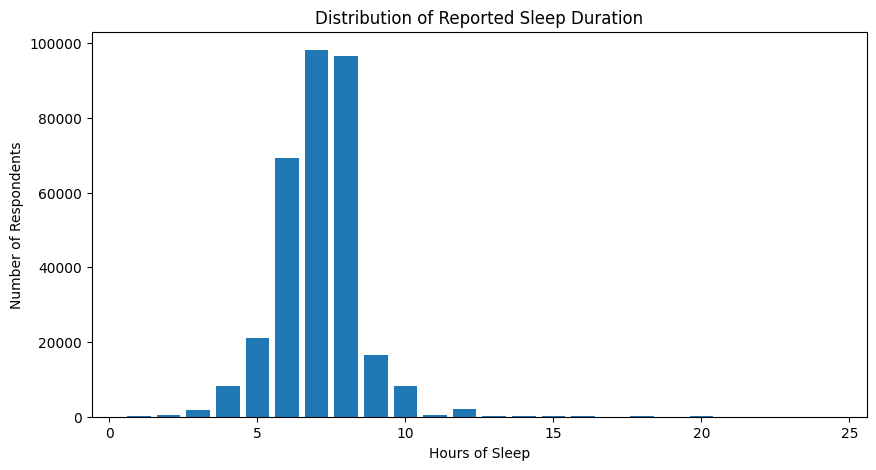

In [65]:
# visualize sleep distribution statistics 
sleep_counts = analysis_df["sleep_hours"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(sleep_counts.index, sleep_counts.values)

plt.xlabel("Hours of Sleep")
plt.ylabel("Number of Respondents")
plt.title("Distribution of Reported Sleep Duration")

plt.show()

Most respondents reported sleeping between 6 and 8 hours per night, with 7 and 8 hours being the most common. Very short and very long sleep durations were much less common.

## Mental Health Data

Quick recap of the survey question: 
Question: Now thinking about your mental health, which includes stress, depression, and problems with emotions, for how many days during the past 30 days was your mental health not good?

In [67]:
# summarize poor mental health days
analysis_df["poor_mental_health_days"].describe()

count    323552.000000
mean          4.543094
std           8.467473
min           0.000000
25%           0.000000
50%           0.000000
75%           5.000000
max          30.000000
Name: poor_mental_health_days, dtype: float64

The median respondent reported 0 poor mental health days, while the average was about 4.5 days per month. This suggests that many respondents reported no poor mental health days, while a smaller group reported much higher values.

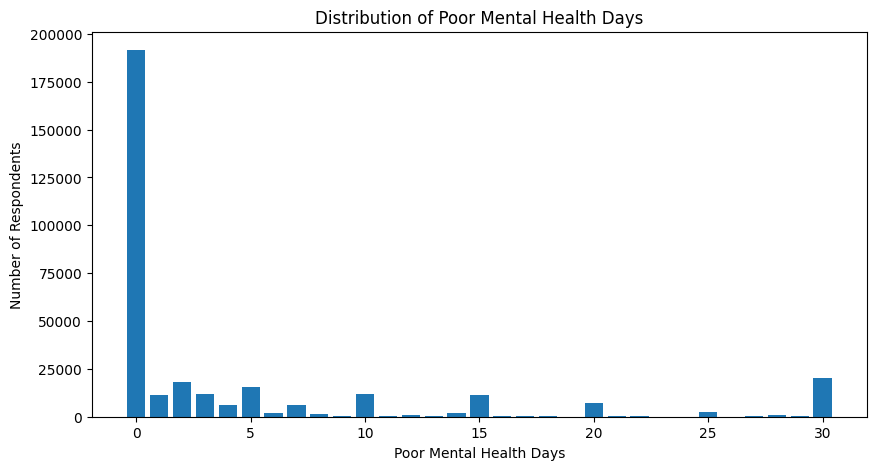

In [68]:
# count respondents for each number of poor mental health days
mental_health_counts = analysis_df["poor_mental_health_days"].value_counts().sort_index()

# visualize the distribution
plt.figure(figsize=(10, 5))
plt.bar(mental_health_counts.index, mental_health_counts.values)

# add labels and title
plt.xlabel("Poor Mental Health Days")
plt.ylabel("Number of Respondents")
plt.title("Distribution of Poor Mental Health Days")

plt.show()

The skewness of the data becomes more obvious in the bar chart. Most respondents reported 0 poor mental health days, while a smaller number reported higher values, including 30 days.

In [69]:
# calculate average poor mental health days for each sleep duration
sleep_mental_health = (
    analysis_df.groupby("sleep_hours")["poor_mental_health_days"]
    .mean()
    .reset_index()
)

# view the results
sleep_mental_health

,sleep_hours,poor_mental_health_days
0,1.0,14.621359
1,2.0,13.526971
2,3.0,13.786644
3,4.0,11.731516
4,5.0,8.266670
5,6.0,5.591991
6,7.0,3.447856
7,8.0,3.145971
8,9.0,3.705412
9,10.0,5.762503


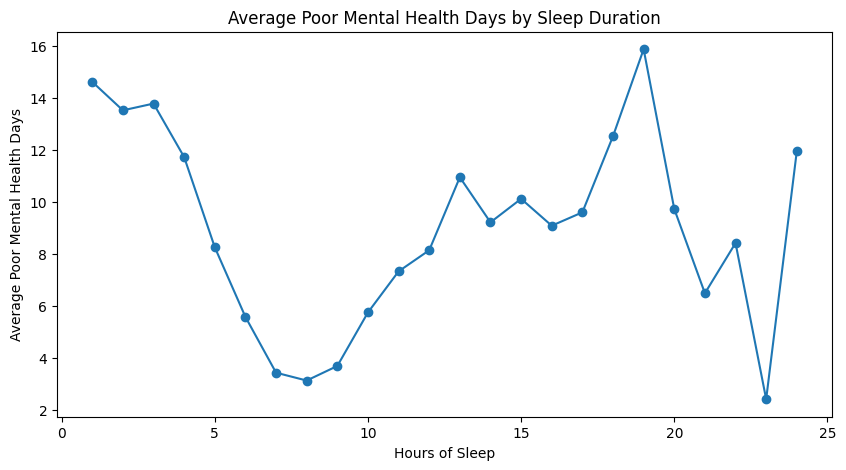

In [70]:
# visualize average poor mental health days by sleep duration
plt.figure(figsize=(10, 5))

plt.plot(
    sleep_mental_health["sleep_hours"],
    sleep_mental_health["poor_mental_health_days"],
    marker="o"
)

# add labels and title
plt.xlabel("Hours of Sleep")
plt.ylabel("Average Poor Mental Health Days")
plt.title("Average Poor Mental Health Days by Sleep Duration")

plt.show()

The relationship shows a clear pattern around typical sleep durations. Average poor mental health days decrease as sleep approaches 7–8 hours, then generally increase again with longer sleep durations. The extreme sleep durations are less consistent because fewer respondents reported those values.

## Feature Engineering

To make sleep duration easier to compare, I grouped respondents into short, recommended, and long sleep categories.

In [73]:
# create sleep categories based on reported hours of sleep
analysis_df["sleep_category"] = pd.cut(
    analysis_df["sleep_hours"],
    bins=[0, 7, 9, 25], #keep 24 
    labels=["Short Sleep", "Recommended Sleep", "Long Sleep"],
    right=False
)

# check the number of respondents in each category
analysis_df["sleep_category"].value_counts()

sleep_category
Recommended Sleep    194562
Short Sleep          100921
Long Sleep            28069
Name: count, dtype: int64

In [74]:
# calculate average poor mental health days for each sleep category
category_mental_health = (
    analysis_df.groupby("sleep_category", observed=True)["poor_mental_health_days"]
    .mean()
)

# view the results
category_mental_health

sleep_category
Short Sleep          6.839122
Recommended Sleep    3.298234
Long Sleep           4.916634
Name: poor_mental_health_days, dtype: float64

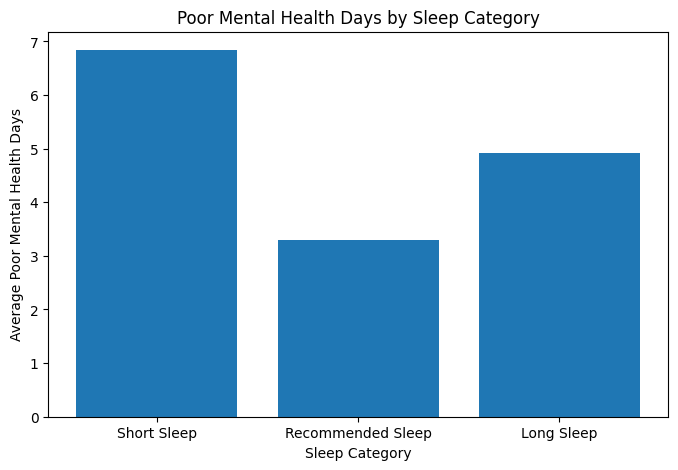

In [75]:
# visualize average poor mental health days for each sleep category
plt.figure(figsize=(8, 5))

plt.bar(
    category_mental_health.index,
    category_mental_health.values
)

# add labels and title
plt.xlabel("Sleep Category")
plt.ylabel("Average Poor Mental Health Days")
plt.title("Poor Mental Health Days by Sleep Category")

plt.show()

Respondents in the recommended sleep group reported the fewest poor mental health days on average. 

Short sleepers reported the most, while long sleepers also reported more poor mental health days than those getting the recommended amount of sleep.

In [76]:
# check the age groups in the cleaned data
analysis_df["age_group"].value_counts().sort_index()

age_group
1.0     21023
2.0     33822
3.0     40641
4.0     42964
5.0     55338
6.0    129764
Name: count, dtype: int64

In [77]:
# create readable labels for the age groups
age_labels = {
    1: "18-24",
    2: "25-34",
    3: "35-44",
    4: "45-54",
    5: "55-64",
    6: "65+"
}

analysis_df["age_category"] = analysis_df["age_group"].map(age_labels)

# check the new age categories
analysis_df["age_category"].value_counts().sort_index()

age_category
18-24     21023
25-34     33822
35-44     40641
45-54     42964
55-64     55338
65+      129764
Name: count, dtype: int64

### Question to be answered: 

Does the relationship between sleep and poor mental health look different across age groups?


In [78]:
# calculate average poor mental health days by age and sleep category
age_sleep_mental_health = (
    analysis_df.groupby(
        ["age_category", "sleep_category"],
        observed=True
    )["poor_mental_health_days"]
    .mean()
    .unstack()
)

# view the results
age_sleep_mental_health.round(2)

sleep_category,Short Sleep,Recommended Sleep,Long Sleep
age_category,,,
18-24,9.10,5.24,6.33
25-34,8.90,4.95,6.65
35-44,8.56,4.39,7.18
45-54,7.88,3.76,7.03
55-64,6.89,3.14,6.59
65+,4.34,2.19,3.54


A sleep pattern does exists across age groups. It seem as if Younger adults report more poor mental-health days overall.

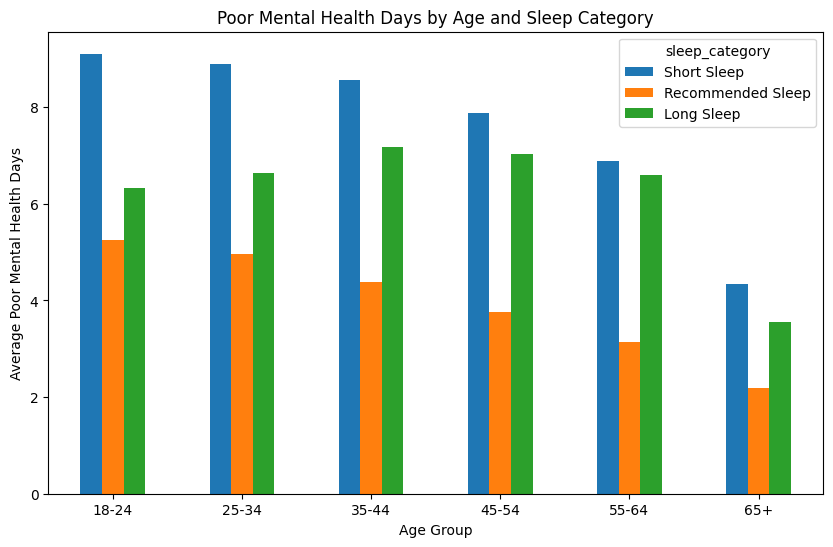

In [79]:
# visualize mental health by age and sleep category
age_sleep_mental_health.plot(
    kind="bar",
    figsize=(10, 6)
)

# add labels and title
plt.xlabel("Age Group")
plt.ylabel("Average Poor Mental Health Days")
plt.title("Poor Mental Health Days by Age and Sleep Category")

# make age labels easier to read
plt.xticks(rotation=0)

plt.show()

Across every age group, respondents getting the recommended amount of sleep reported fewer poor mental health days than short or long sleepers. Poor mental health days also generally decreased with age, with younger adults reporting higher averages.